In [5]:
import opt_einsum as oe
import numpy as np
import torch
import sys
sys.path.append("../../")
import mps
from mps.trainer.data_utils import SyntheticDataset, SyntheticDatasetV2, SyntheticDatasetV3

In [6]:
N = 20
dataset = SyntheticDatasetV3(n=N, num_samples=(2**25), seed=42)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=2**13, shuffle=True)
def calculate_accuracy(outputs, labels):
    """
    Compute accuracy by thresholding outputs at 0.5.
    """
    predictions = (outputs < 0.5).float()
    correct = (predictions == labels).float().sum()
    return correct / labels.numel()

In [9]:
from mps import tpcp_mps
chi = 2
d = 2
l = 2
device = torch.device("cpu")
dtype = torch.float64
optimize = "greedy"
tpcp = tpcp_mps.MPSTPCP(N = N, K = 1, d = d, enable_r=True)

In [10]:
from mps.trainer.utils import focal_loss
data, target = next(iter(dataloader))
data_flip = data.clone()
data_flip[:, 0, :] = 1 - data_flip[:, 0, :]
data = torch.cat((data, data_flip), dim=0)
target = torch.cat((target, 1 - target), dim=0)
output = tpcp(data, return_probs=True)
loss = focal_loss(output, target)
loss.backward()
# print(loss)

i = -2
g = tpcp.kraus_ops[i].grad.reshape(d**2, d**2)
u = tpcp.kraus_ops[i].reshape(d**2, d**2)
rg = u.T @ g - g.T @ u

print(rg)
# print(torch.linalg.norm(rg))
# print(u)
# # print(output[0] - output[round(len(output) / 2)])
# print(output[0])

tensor([[ 0.0000, -0.0077,  0.0056,  0.0129],
        [ 0.0077,  0.0000,  0.0169,  0.0128],
        [-0.0056, -0.0169,  0.0000, -0.0018],
        [-0.0129, -0.0128,  0.0018,  0.0000]], dtype=torch.float64,
       grad_fn=<SubBackward0>)


In [11]:
# hadamard
H = torch.tensor([[1, 1], [1, -1]], dtype=torch.float64) / np.sqrt(2)
U = torch.kron(H, H)
# tpcp.kraus_ops[-1].data[:] = U


In [12]:
x0 = torch.tensor([0, 1], dtype=torch.float64)
x1 = torch.tensor([1, 0], dtype=torch.float64)
# U = tpcp.kraus_ops[-3].reshape(d**2, d**2)
rho0 = torch.einsum("i, j->ij", x0, x0)
rho1 = torch.einsum("i, j->ij", x1, x1)
rho = torch.einsum("ij, kl->ikjl", rho0, rho1).reshape(d**2, d**2)

rho = U.T @ rho @ U

rho


tensor([[ 0.2500,  0.2500, -0.2500, -0.2500],
        [ 0.2500,  0.2500, -0.2500, -0.2500],
        [-0.2500, -0.2500,  0.2500,  0.2500],
        [-0.2500, -0.2500,  0.2500,  0.2500]], dtype=torch.float64)

In [16]:
from geoopt import optim
# from mps.unitary_optimizer import Adam
from mps.trainer.utils import focal_loss
from mps.trainer.utils import calculate_accuracy

optimizer = optim.RiemannianAdam(tpcp.kraus_ops.parameters(), lr=0.01)

for data, target in dataloader:
# for _ in range(1000):
    data, target = next(iter(dataloader))
    data_flip = data.clone()
    data_flip[:, 0, :] = 1 - data_flip[:, 0, :]
    data = torch.cat((data, data_flip), dim=0)
    target = torch.cat((target, 1 - target), dim=0)
    optimizer.zero_grad()

    outputs = tpcp(data, return_probs=True)
    loss = focal_loss(outputs, target)
    loss.backward()
    preds = outputs.argmax(dim=-1)
    acc = (preds == target).float().mean().item()
    # print(loss.item(), (outputs[0] - outputs[round(len(outputs) / 2)]).detach().numpy(), acc)
    print(loss.item(), outputs[0].detach().numpy(), acc)

    i = 0
    g = tpcp.kraus_ops[i].grad.reshape(d**2, d**2)
    u = tpcp.kraus_ops[i].reshape(d**2, d**2)
    rg = u.T @ g - g.T @ u

    # print(rg)
    print(torch.linalg.norm(rg))

    optimizer.step()

0.3471988150625024 [0.48928955 0.51071045] 0.50006103515625
tensor(2.0194e-06, dtype=torch.float64, grad_fn=<LinalgVectorNormBackward0>)
0.34744517488348303 [0.46502329 0.53497671] 0.5001220703125
tensor(1.5512e-06, dtype=torch.float64, grad_fn=<LinalgVectorNormBackward0>)
0.3467181607076782 [0.48875274 0.51124726] 0.49993896484375
tensor(2.1823e-06, dtype=torch.float64, grad_fn=<LinalgVectorNormBackward0>)
0.34677444902337784 [0.49334777 0.50665223] 0.50006103515625
tensor(3.8844e-07, dtype=torch.float64, grad_fn=<LinalgVectorNormBackward0>)
0.3469418414035923 [0.50974066 0.49025934] 0.5
tensor(7.4131e-07, dtype=torch.float64, grad_fn=<LinalgVectorNormBackward0>)
0.3467582584902745 [0.49272022 0.50727978] 0.5
tensor(2.6956e-07, dtype=torch.float64, grad_fn=<LinalgVectorNormBackward0>)
0.34659249504174816 [0.49962492 0.50037508] 0.50018310546875
tensor(8.6059e-08, dtype=torch.float64, grad_fn=<LinalgVectorNormBackward0>)
0.3466558079320644 [0.50337763 0.49662237] 0.5
tensor(6.8639e-08,

: 

In [7]:
from geoopt import optim
from mps.unitary_optimizer import Adam

# optimizer = optim.RiemannianAdam(umps.parameters(), lr=0.0001)
optimizer = Adam(umps, lr=0.0001)

for data, target in dataloader:

    target_flip = 1 - target
    data_flip = data.clone()
    data_flip[:, 0, :] = 1 - data_flip[:, 0, :]
    target = torch.cat((target, target_flip), dim=0)
    data = torch.cat((data, data_flip), dim=0)

    optimizer.zero_grad()
    output = umps(data.permute(1, 0, 2))
    loss = focal_loss(output, target)
    loss.backward()
    optimizer.step()
    u = umps.params[0].reshape(4, 4)
    acc = calculate_accuracy(output, target)

    print("loss", loss, "acc", acc)

loss tensor([0.9370], dtype=torch.float64, grad_fn=<DivBackward0>) acc tensor(0.5010)
loss tensor([1.0235], dtype=torch.float64, grad_fn=<DivBackward0>) acc tensor(0.5000)
loss tensor([1.0190], dtype=torch.float64, grad_fn=<DivBackward0>) acc tensor(0.5000)
loss tensor([1.0262], dtype=torch.float64, grad_fn=<DivBackward0>) acc tensor(0.5000)
loss tensor([1.0189], dtype=torch.float64, grad_fn=<DivBackward0>) acc tensor(0.5000)
loss tensor([1.0238], dtype=torch.float64, grad_fn=<DivBackward0>) acc tensor(0.5000)
loss tensor([1.0201], dtype=torch.float64, grad_fn=<DivBackward0>) acc tensor(0.5000)
loss tensor([1.0259], dtype=torch.float64, grad_fn=<DivBackward0>) acc tensor(0.5000)
loss tensor([1.0220], dtype=torch.float64, grad_fn=<DivBackward0>) acc tensor(0.5000)
loss tensor([1.0101], dtype=torch.float64, grad_fn=<DivBackward0>) acc tensor(0.5000)
loss tensor([1.0169], dtype=torch.float64, grad_fn=<DivBackward0>) acc tensor(0.5000)
loss tensor([1.0252], dtype=torch.float64, grad_fn=<Di

KeyboardInterrupt: 

In [74]:
data1 = data.clone()

data1[:, 0, :] = 1 - data1[:, 0, :]

In [75]:
umps(data.permute(1, 0, 2)), umps(data1.permute(1, 0, 2))

(tensor([0.4984, 0.5552, 0.5214,  ..., 0.5059, 0.5186, 0.4657],
        dtype=torch.float64, grad_fn=<ViewBackward0>),
 tensor([0.4984, 0.5552, 0.5214,  ..., 0.5059, 0.5186, 0.4657],
        dtype=torch.float64, grad_fn=<ViewBackward0>))

In [67]:
import opt_einsum as oe
import numpy as np
import torch
import sys
sys.path.append("../../")
import mps
from mps.trainer.data_utils import SyntheticDatasetV3
from mps.simple_mps import SimpleMPS
import matplotlib.pyplot as plt

# Fixed parameters for the model
chi = 2
d = 2
l = 2
device = torch.device("cpu")
dtype = torch.float64
optimize = "greedy"

# List of different system sizes to test
# N_list = [10, 20, 40, 80, 160, 320, 400, 500, 600, 700, 800, 900, 1000]
N_list = [10, 20, 40, 80, 160, 320, 400, ]
N_list = np.round(N_list).astype(int)
# N_list = [int(50 * (1.5 ** i for i in range(5)]
num_experiments = 10000
# Batch size for data (can be adjusted as needed)
batch_size = 100

# Lists to store the averaged gradient statistics for each system size
avg_means = []
avg_vars = []

for N in N_list:
    print(N)
    experiment_means = []
    experiment_vars = []
    
    # Create a dataset for this system size (using a moderate number of samples)
    dataset = SyntheticDatasetV3(n=N, num_samples=2**15, seed=42)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # Get one batch of data and labels
    data, target = next(iter(dataloader))
    
    # Increase the data
    data_flipped = data.clone()
    data_flipped[:, 0] = 1 - data_flipped[:, 0]  # Flip the first element in each data in the batch
    target_flipped = 1 - target  # Flip the target
    
    # Concatenate the original and flipped data and targets
    data = torch.cat((data, data_flipped), dim=0)
    target = torch.cat((target, target_flipped), dim=0)
    
    # Run several experiments to average out the gradient behavior
    for exp in range(num_experiments):
        # For each experiment, create a fresh model.
        # Here, eps is chosen as 1/N, similar to your original code.
        eps = 1 / np.sqrt(N) * 0.1
        seed = np.random.randint(0, 1000000)
        smps = SimpleMPS(N, chi, d, l, layers=1, device=device, dtype=dtype, optimize=optimize, eps=eps, seed=seed)
        
        # Forward pass (note the permutation as in your code)
        output = smps(data.permute(1, 0, 2))
        
        # Compute the loss (using LogSoftmax and NLLLoss as before)
        logsoftmax = torch.nn.LogSoftmax(dim=-1)
        nnloss = torch.nn.NLLLoss(reduction="mean")
        ls = logsoftmax(output)
        loss = nnloss(ls, target)
        
        # Backward pass to compute gradients
        loss.backward()
        
        # Extract the gradient for the parameters of interest.
        # Here, we choose the parameters at index 0 and -2 (as in your snippet).
        grad_param_0 = smps.mps.params[0].grad
        grad_param_neg2 = smps.mps.params[-1].grad
        
        # Calculate mean and variance over all gradient matrix elements for both parameters.
        mean_grad_0 = grad_param_0.norm()
        var_grad_0 = grad_param_0.var().item()
        
        mean_grad_neg2 = grad_param_neg2.norm()
        var_grad_neg2 = grad_param_neg2.var().item()
        
        experiment_means.append((mean_grad_0, mean_grad_neg2))
        experiment_vars.append((var_grad_0, var_grad_neg2))
    
    # Average the gradient statistics over the experiments for this system size.
    avg_means.append((np.mean([m[0] for m in experiment_means]), np.mean([m[1] for m in experiment_means])))
    avg_vars.append((np.mean([v[0] for v in experiment_vars]), np.mean([v[1] for v in experiment_vars])))


10
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the

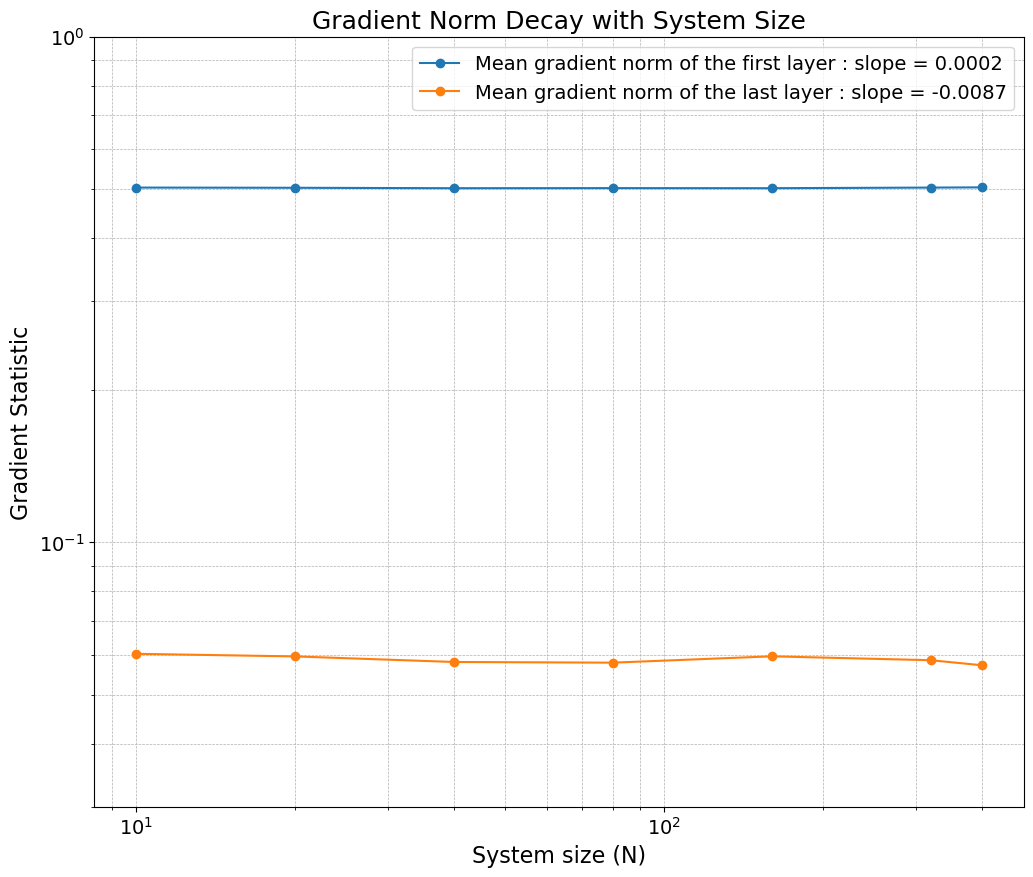

In [86]:
# Perform a linear fit on the log-log scale data for both gradients
log_N_list = np.log(N_list)
log_avg_means_0 = np.log([m[0] for m in avg_means])
log_avg_means_neg2 = np.log([m[1] for m in avg_means])
slope_0, intercept_0 = np.polyfit(log_N_list, log_avg_means_0, 1)
slope_neg2, intercept_neg2 = np.polyfit(log_N_list, log_avg_means_neg2, 1)

# Plot the mean gradient norm for both parameters vs system size in a log-log scale.
plt.figure(figsize=(12, 10))  # Increase figure size
plt.loglog(N_list, [m[0] for m in avg_means], marker='o', label=f'Mean gradient norm of the first layer : slope = {slope_0:.4f}')
plt.loglog(N_list, [m[1] for m in avg_means], marker='o', label=f'Mean gradient norm of the last layer : slope = {slope_neg2:.4f}')
plt.xlabel("System size (N)", fontsize=16)  # Increase font size
plt.ylabel("Gradient Statistic", fontsize=16)  # Increase font size
plt.title(f"Gradient Norm Decay with System Size", fontsize=18)  # Increase font size
plt.legend(fontsize=14)  # Increase font size
plt.grid(True, which="both", linestyle='--', linewidth=0.5)  # Add grid
plt.ylim(0.03, 1)
plt.xticks(fontsize=14)  # Increase tick font size
plt.yticks(fontsize=14)  # Increase tick font size
plt.show()

In [53]:
import opt_einsum as oe
import numpy as np
import torch
import sys
sys.path.append("../../")
import mps
from mps.trainer.data_utils import SyntheticDatasetV3
from mps.simple_mps import SimpleMPS
import matplotlib.pyplot as plt


# Fixed parameters for the model
chi = 2
d = 2
l = 2
device = torch.device("cpu")
dtype = torch.float64
optimize = "greedy"

N = 100
# Batch size for data (can be adjusted as needed)
batch_size = 100

print(N)
experiment_means = []
experiment_vars = []

# Create a dataset for this system size (using a moderate number of samples)
# dataset = SyntheticDatasetV3(n=N, num_samples=2**15, seed=42)
# dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Get one batch of data and labels
data = torch.zeros(N, 2)
data[:, 0] = 1
data_flipped = data.clone()
data_flipped[0, :] = torch.tensor([0, 1])
data = torch.stack((data, data_flipped), dim=0)
target = torch.tensor([0, 1])
# # data, target = next(iter(dataloader))

# # Increase the data
# data_flipped = data.clone()
# data_flipped[:, 0] = 1 - data_flipped[:, 0]  # Flip the first element in each data in the batch
# target_flipped = 1 - target  # Flip the target

# # Concatenate the original and flipped data and targets
# data = torch.cat((data, data_flipped), dim=0)
# target = torch.cat((target, target_flipped), dim=0)

# For each experiment, create a fresh model.
# Here, eps is chosen as 1/N, similar to your original code.
eps = 1 / np.sqrt(N) * 0.1
seed = np.random.randint(0, 1000000)
smps = SimpleMPS(N, chi, d, l, layers=1, device=device, dtype=dtype, optimize=optimize, eps=eps, seed=seed)
smps.mps.convert_to_canonical()
smps.initialize_MPS()
optimizer = torch.optim.Adam(smps.mps.params.parameters(), lr=0.0001)



100
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Initialized MPS with random matrices


In [54]:
import torch

# Forward pass (note the permutation as in your code)
output = smps(data.permute(1, 0, 2))

optimizer.zero_grad()
for param in smps.mps.params:
    if param.grad is not None:
        param.grad.zero_()


# Compute the loss (using LogSoftmax and NLLLoss as before)
logsoftmax = torch.nn.LogSoftmax(dim=-1)
nnloss = torch.nn.NLLLoss(reduction="mean")
ls = logsoftmax(output)
loss = nnloss(ls, target)

# Backward pass to compute gradients
loss.backward()
print(loss)

tensor(0.6931, dtype=torch.float64, grad_fn=<NllLossBackward0>)


In [55]:
loss

tensor(0.6931, dtype=torch.float64, grad_fn=<NllLossBackward0>)

In [56]:
output

tensor([[5.3053e-16, 6.6644e-16],
        [5.3653e-16, 6.5958e-16]], dtype=torch.float64, grad_fn=<AbsBackward0>)

In [60]:
smps.mps.params[-2].grad

tensor([[[-4.9533e-20,  4.5316e-20],
         [ 0.0000e+00,  0.0000e+00]],

        [[-4.9260e-18,  4.5066e-18],
         [ 0.0000e+00,  0.0000e+00]]], dtype=torch.float64)

In [292]:
output

tensor([[1.0004, 0.9986],
        [1.0004, 0.9986]], dtype=torch.float64, grad_fn=<AbsBackward0>)

In [293]:
ls - torch.log(torch.tensor(1/2))

tensor([[ 0.0009, -0.0009],
        [ 0.0009, -0.0009]], dtype=torch.float64, grad_fn=<SubBackward0>)

In [288]:
ls

tensor([[-0.6923, -0.6940],
        [-0.6923, -0.6940]], dtype=torch.float64,
       grad_fn=<LogSoftmaxBackward0>)

In [6]:
loss

tensor(0.6932, dtype=torch.float64, grad_fn=<NllLossBackward0>)

tensor([[[ 0.0012, -0.0012],
         [ 0.0000,  0.0000]],

        [[ 0.0012, -0.0012],
         [ 0.0000,  0.0000]]], dtype=torch.float64)